This notebook runs the code used to select my objects

In [63]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, join
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

### Read in dataset from ViZieR

In [2]:
#opening Greene & Ho (2007) dataset
data= Table.read('/home/hernab6/Downloads/asu.fit')
print(data)
print(np.shape(data))


Seq         SDSS           z    Sloan ... logLbol    _RA       _DE     recno  
                                      ...            deg       deg            
--- ------------------- ------- ----- ... ------- --------- --------- --------
  1 J000111.15-100155.5  0.0489 Sloan ...    -1.6   0.29646 -10.03208        1
  2 J000308.47+154842.3  0.1180 Sloan ...    -0.5   0.78529  15.81175        2
  3 J000605.59-092007.0  0.0699 Sloan ...    -1.4   1.52329  -9.33528        3
  4 J001728.84-001826.7  0.1110 Sloan ...    -0.8   4.37017  -0.30742        4
  5 J002228.36-005830.6  0.1060 Sloan ...    -0.3   5.61817  -0.97517        5
  6 J002452.53-103819.6  0.1030 Sloan ...    -0.7   6.21887 -10.63878        6
  7 J003552.26+011249.4  0.0414 Sloan ...    -1.7   8.96775   1.21372        7
  8 J004042.10-110957.6  0.0274 Sloan ...    -1.6  10.17542 -11.16600        8
  9 J005633.36+000510.1  0.0793 Sloan ...    -0.7  14.13900   0.08614        9
 10 J010600.56+152441.9  0.2040 Sloan ...    -0.2  1

In [3]:
print(data['z'].min())

0.0056


### Redshift Cut

In [4]:
from astropy.cosmology import FlatLambdaCDM


cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.20

# tan(x) = Distance / Physical Size --> small angle approx --> x ~ Distance/physical size --> Physical size = x * Distance
DA = cosmo.angular_diameter_distance(z).value  # angular diameter distance [Mpc]
theta= np.pi/180* 1/(3600) # arcseconds in 1 degree

scale_kpc_per_arcsec = theta * DA*1000 #multiplied DA by 1000 to get to kpc scales
print(scale_kpc_per_arcsec, "kpc/arcsec")

pixel_scale= 0.2637 #arcsec/pix

print((pixel_scale* scale_kpc_per_arcsec),"kpc/pixel")

3.2996549997814983 kpc/arcsec
0.8701190234423811 kpc/pixel


From `./proposal_outline.ipynb`, I deduced (code copied in the cell above) that a redshift cut of $z \leq 0.2$ would have spatial resolution that corresponds to a physical size less than 1 kpc per pixel; this allows better isolation from host galaxy by mimizing contamination from host.

### Redshift Cut

In [5]:
##### first a redshift cut
local_z= data['z'] <= 0.2
data_z= data[local_z]
print(len(data_z))

220


### Make an RA, Dec .txt file
This file will contain the RA and Dec for the objects after the redshift cut so I can query their g and r band magnitude on SDSS Cross ID webpage

In [6]:
data_z.colnames

['Seq',
 'SDSS',
 'z',
 'Sloan',
 'Hbn',
 'Hbb',
 'Han',
 'Hab',
 'W_Ha',
 'logMBH',
 'logLbol',
 '_RA',
 '_DE',
 'recno']

In [7]:
#create my own ID numbers to make merging easier later
numbered= np.arange(1,len(data_z)+1)
print(numbered)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220]


In [8]:
#create column with new IDs ('name')
data_z['name'] = numbered

In [9]:
#write the file to upload 
subset = data_z['name','_RA', '_DE']
subset.write('targets.txt', format='ascii.basic', overwrite=True)

With this `target.txt` file I was able to successfully query the objects and obtain theri r-band and g-band magnitudes

In [10]:
from astropy.table import Table

sdss = Table.read('/home/hernab6/Downloads/SDSS_results.csv', format='csv', header_start=1)
print(sdss)

name        objID        name1 modelMag_g modelMag_r
---- ------------------- ----- ---------- ----------
   1 1237652947452035132     1   18.55947   17.80087
   2 1237656496724639896     2   18.32434   17.72196
   3 1237652948526301299     3   17.97019   17.21685
   4 1237663783662452843     4   17.87867   17.13681
   5 1237657189833900309     5   19.10671   18.32462
   6 1237652629101281403     6   18.54961   17.81438
   7 1237657192519762033     7   18.66779   18.28379
   8 1237652628566114405     8   17.46799   16.74142
   9 1237663784203583705     9   19.45788   18.92237
  10 1237666216217280598    10   18.36997   17.79146
 ...                 ...   ...        ...        ...
 210 1237651213362987445   210   19.21127   18.67212
 211 1237652934568771867   211    18.2965   17.94131
 212 1237678617937707478   212    19.2552   18.55723
 213 1237652598492824000   213   18.90085   18.32308
 214 1237656567044964745   214    19.7051   18.78021
 215 1237663543146840502   215   20.89601    2

In [11]:
merged = join(data_z, sdss, keys='name', join_type='left') #merged with the 'name' column i added
print(merged)

Seq         SDSS           z    Sloan ... name1 modelMag_g modelMag_r
                                      ...                            
--- ------------------- ------- ----- ... ----- ---------- ----------
  1 J000111.15-100155.5  0.0489 Sloan ...     1   18.55947   17.80087
  2 J000308.47+154842.3  0.1180 Sloan ...     2   18.32434   17.72196
  3 J000605.59-092007.0  0.0699 Sloan ...     3   17.97019   17.21685
  4 J001728.84-001826.7  0.1110 Sloan ...     4   17.87867   17.13681
  5 J002228.36-005830.6  0.1060 Sloan ...     5   19.10671   18.32462
  6 J002452.53-103819.6  0.1030 Sloan ...     6   18.54961   17.81438
  7 J003552.26+011249.4  0.0414 Sloan ...     7   18.66779   18.28379
  8 J004042.10-110957.6  0.0274 Sloan ...     8   17.46799   16.74142
  9 J005633.36+000510.1  0.0793 Sloan ...     9   19.45788   18.92237
 11 J010712.03+140844.9  0.0767 Sloan ...    10   18.36997   17.79146
...                 ...     ...   ... ...   ...        ...        ...
219 J205822.14-06500

### r-band magnitude cut

I chose an r-band cut of $ r \leq 20$ to ensure we have enough brightness to notice variability

In [12]:
r_threshold= merged['modelMag_r'] <= 20.0
final_sample = merged[r_threshold]
print(final_sample)

Seq         SDSS           z    Sloan ... name1 modelMag_g modelMag_r
                                      ...                            
--- ------------------- ------- ----- ... ----- ---------- ----------
  1 J000111.15-100155.5  0.0489 Sloan ...     1   18.55947   17.80087
  2 J000308.47+154842.3  0.1180 Sloan ...     2   18.32434   17.72196
  3 J000605.59-092007.0  0.0699 Sloan ...     3   17.97019   17.21685
  4 J001728.84-001826.7  0.1110 Sloan ...     4   17.87867   17.13681
  5 J002228.36-005830.6  0.1060 Sloan ...     5   19.10671   18.32462
  6 J002452.53-103819.6  0.1030 Sloan ...     6   18.54961   17.81438
  7 J003552.26+011249.4  0.0414 Sloan ...     7   18.66779   18.28379
  8 J004042.10-110957.6  0.0274 Sloan ...     8   17.46799   16.74142
  9 J005633.36+000510.1  0.0793 Sloan ...     9   19.45788   18.92237
 11 J010712.03+140844.9  0.0767 Sloan ...    10   18.36997   17.79146
...                 ...     ...   ... ...   ...        ...        ...
218 J172759.15+54214

 $\textbf{r-band cut results}$: 208 galaxies

### Sky Distibution

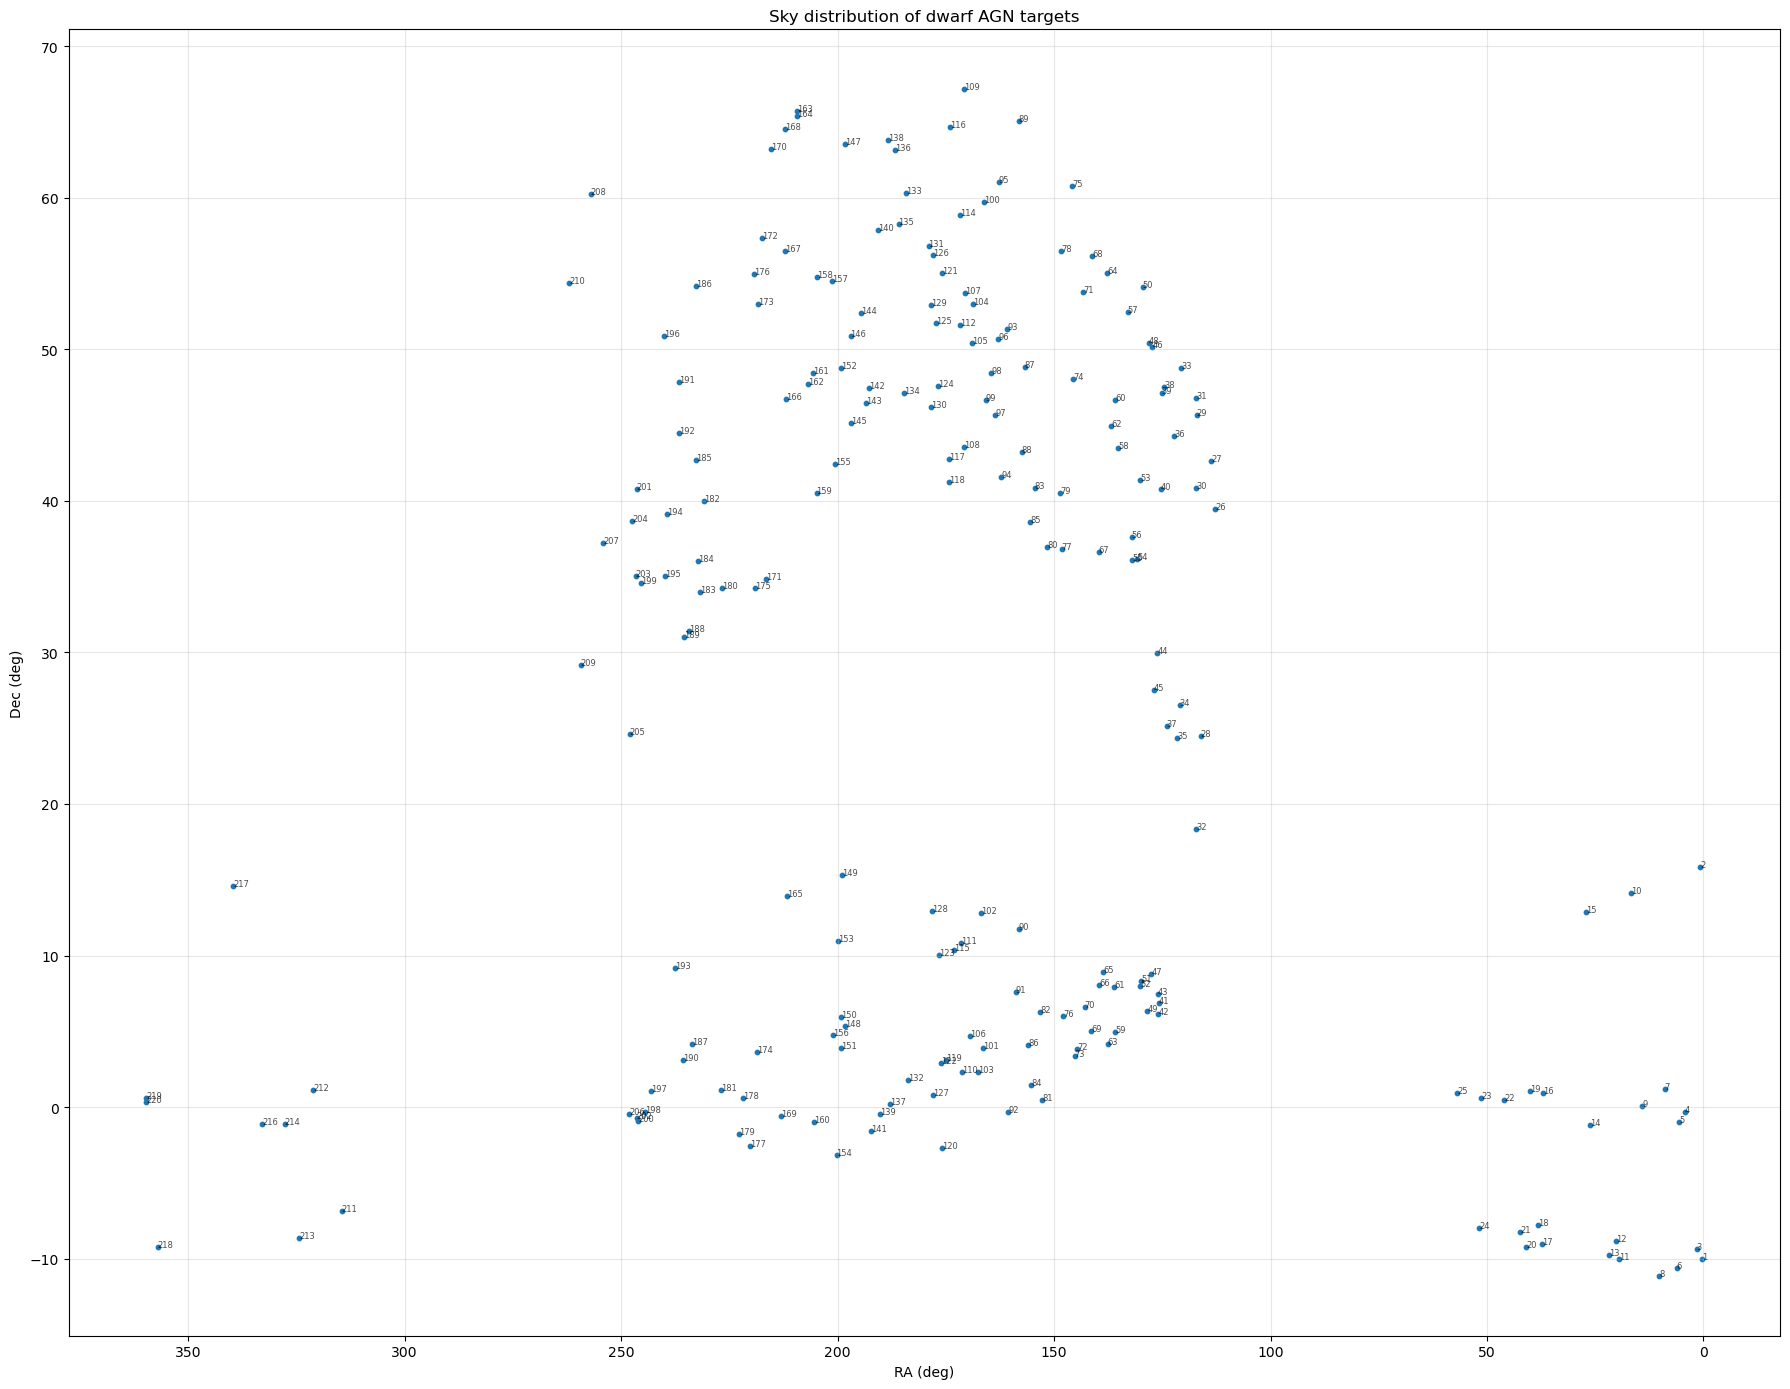

In [13]:
ra = final_sample['_RA']
dec = final_sample['_DE']
names = final_sample['name'] if 'name' in final_sample.colnames else None

plt.figure(figsize=(18, 14))
plt.scatter(ra, dec, s=10)

if names is not None:
    for x, y, n in zip(ra, dec, names):
        plt.text(x, y, n, fontsize=6, alpha=0.7)

plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Sky distribution of dwarf AGN targets')
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Check which objects are visible at CTIO

In [14]:
lat = -30.169  # CTIO latitude in degrees

# Hard visibility limit: never rises if dec > 90 + lat
dec_max_visible = 90 + lat

# Rough airmass<1.5 transit screening
z = np.degrees(np.arccos(1/1.5))   # zenith angle at airmass 1.5
alt = 90 - z
dec_min_airmass = lat - (90 - alt)
dec_max_airmass = lat + (90 - alt)

print("Never rises if dec >", dec_max_visible)
print("Approx transit dec range for airmass < 1.5:", dec_min_airmass, "to", dec_max_airmass)

visible = (final_sample['_DE'] <= dec_max_visible)
good_airmass = (final_sample['_DE'] >= dec_min_airmass) & (final_sample['_DE'] <= dec_max_airmass)

print("Targets above horizon:", np.sum(visible))
print("Targets meeting rough airmass<1.5 transit cut:", np.sum(good_airmass))


Never rises if dec > 59.831
Approx transit dec range for airmass < 1.5: -78.35868510422141 to 18.02068510422141
Targets above horizon: 204
Targets meeting rough airmass<1.5 transit cut: 98


In [15]:
visible_sample=final_sample[good_airmass]
visible_sample

Seq,SDSS,z,Sloan,Hbn,Hbb,Han,Hab,W_Ha,logMBH,logLbol,_RA,_DE,recno,name,objID,name1,modelMag_g,modelMag_r
,,,,,,,,km / s,log(solMass),,deg,deg,,,,,,
int16,bytes19,float32,bytes5,float32,float32,float32,float32,int16,float32,float32,float64,float64,int32,int64,int64,int64,float64,float64
1,J000111.15-100155.5,0.0489,Sloan,0.270,0.410,1.400,1.300,1870,6.2,-1.6,0.29646,-10.03208,1,1,1237652947452035132,1,18.55947,17.80087
2,J000308.47+154842.3,0.1180,Sloan,0.570,1.000,1.900,4.800,976,6.1,-0.5,0.78529,15.81175,2,2,1237656496724639896,2,18.32434,17.72196
3,J000605.59-092007.0,0.0699,Sloan,0.180,0.620,0.690,0.840,1710,6.2,-1.4,1.52329,-9.33528,3,3,1237652948526301299,3,17.97019,17.21685
4,J001728.84-001826.7,0.1110,Sloan,0.610,0.770,2.100,2.400,1180,6.2,-0.8,4.37017,-0.30742,4,4,1237663783662452843,4,17.87867,17.13681
5,J002228.36-005830.6,0.1060,Sloan,0.160,0.520,0.510,3.900,807,6.0,-0.3,5.61817,-0.97517,5,5,1237657189833900309,5,19.10671,18.32462
6,J002452.53-103819.6,0.1030,Sloan,0.680,1.000,3.200,3.200,1070,6.1,-0.7,6.21887,-10.63878,6,6,1237652629101281403,6,18.54961,17.81438
7,J003552.26+011249.4,0.0414,Sloan,0.570,0.630,1.700,2.000,1690,5.8,-1.7,8.96775,1.21372,7,7,1237657192519762033,7,18.66779,18.28379
8,J004042.10-110957.6,0.0274,Sloan,0.600,0.560,1.800,3.600,1530,5.8,-1.6,10.17542,-11.16600,8,8,1237652628566114405,8,17.46799,16.74142


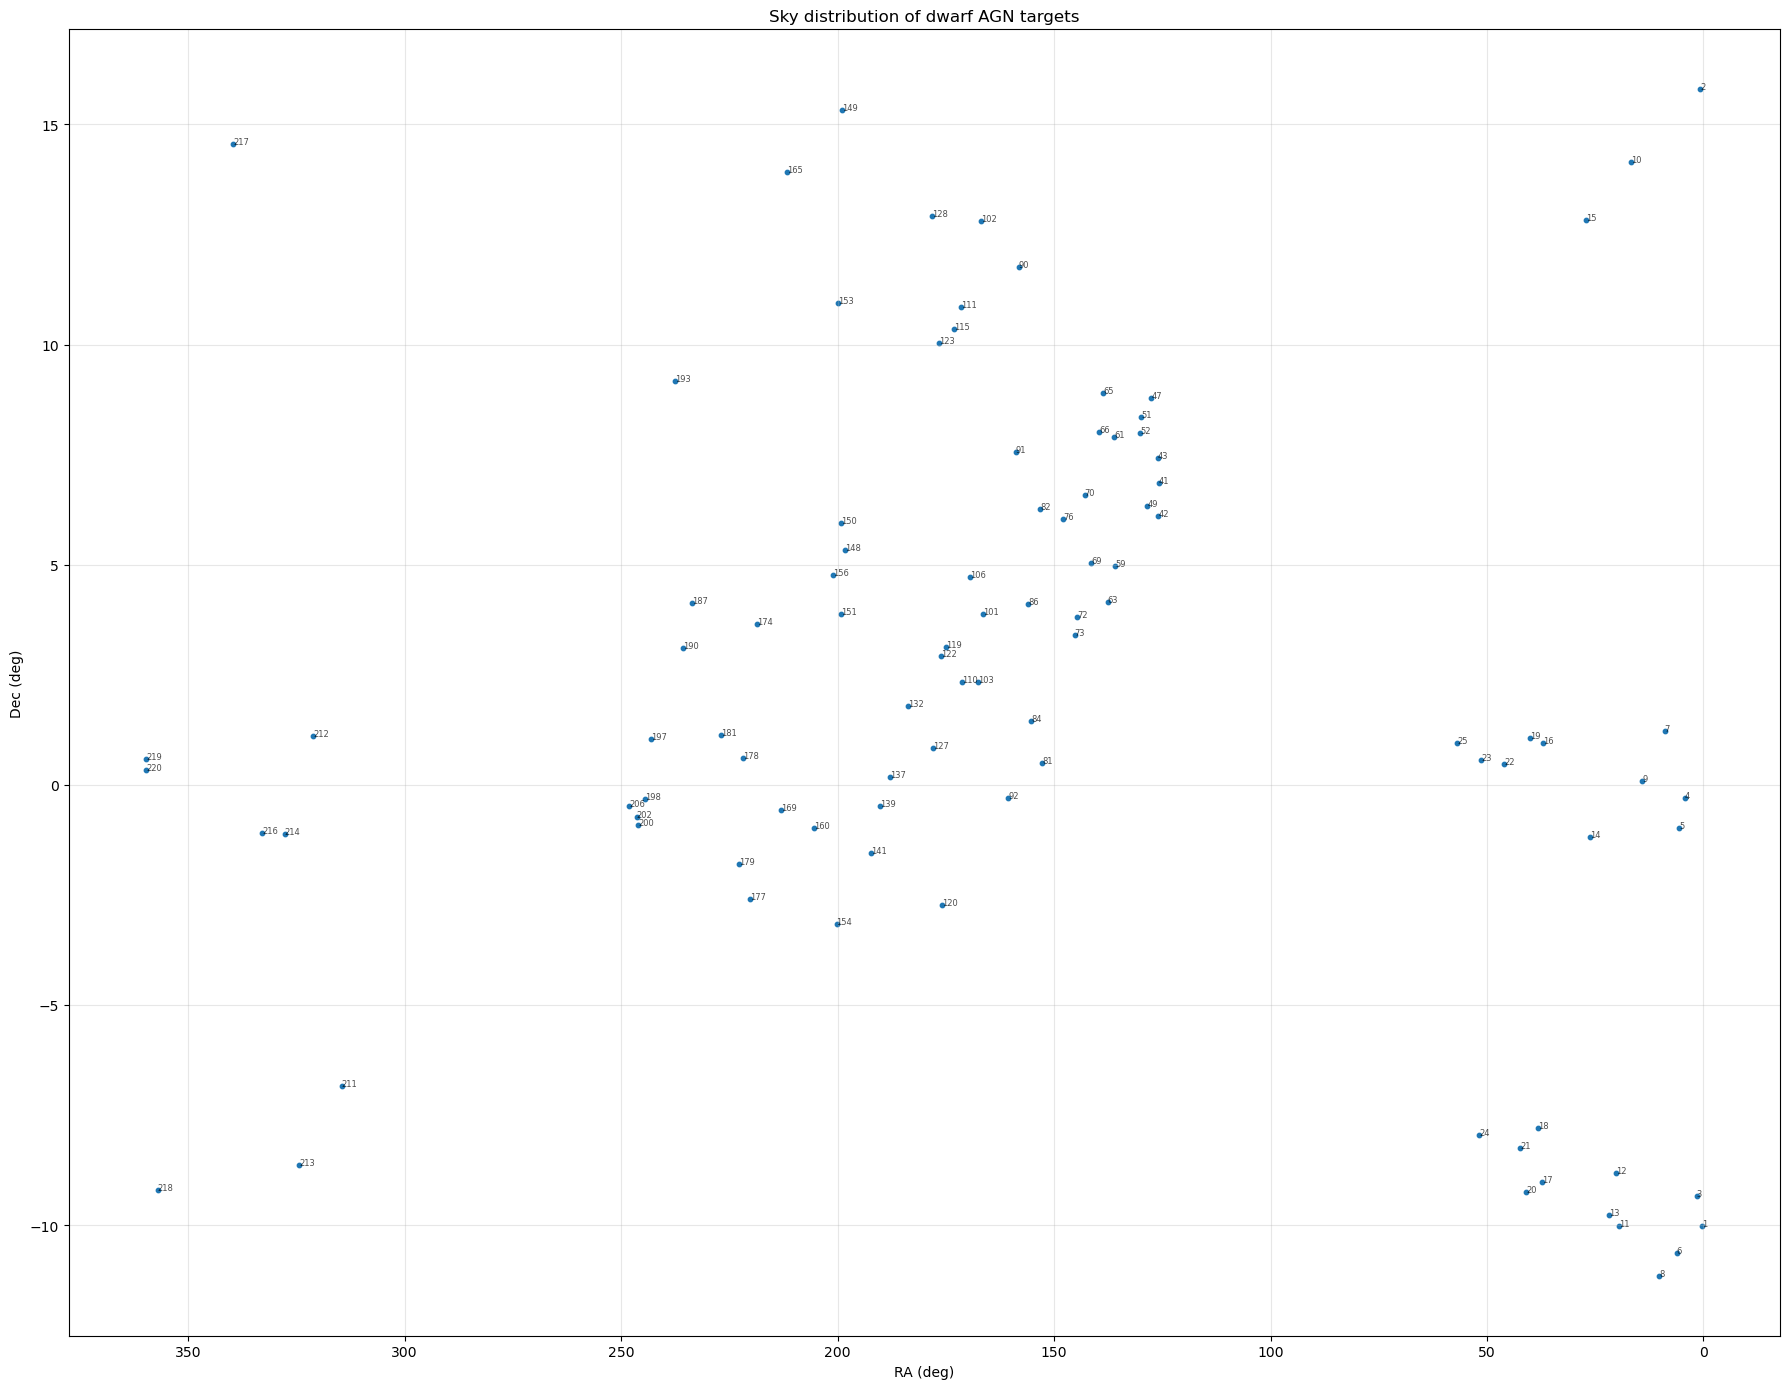

In [16]:
ra = visible_sample['_RA']
dec = visible_sample['_DE']
names = visible_sample['name'] if 'name' in visible_sample.colnames else None

plt.figure(figsize=(18, 14))
plt.scatter(ra, dec, s=10)

if names is not None:
    for x, y, n in zip(ra, dec, names):
        plt.text(x, y, n, fontsize=6, alpha=0.7)

plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Sky distribution of dwarf AGN targets')
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()

In [17]:
#Greedy Clustering algorithm to mazimize objects with as low DECam footprints as possible
ra = np.array(visible_sample['_RA'])
dec = np.array(visible_sample['_DE'])

coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')

field_radius = 1.1 * u.deg   # DECam radius ~ 1.1 deg --> DECam has a circular-ish footprint

remaining = set(range(len(coords)))
clusters = []
labels = -1 * np.ones(len(coords), dtype=int)

cluster_id = 0

while remaining:
    rem = np.array(sorted(remaining))

    # Pairwise separations among the remaining targets
    subcoords = coords[rem]
    sep = subcoords[:, None].separation(subcoords[None, :])

    # Count how many neighbors each remaining object has within one DECam radius
    counts = (sep <= field_radius).sum(axis=1)

    # Choose the densest remaining object as the seed
    seed_pos = np.argmax(counts)

    # All targets within one field radius of the seed
    members_mask = sep[seed_pos] <= field_radius
    members = rem[members_mask]

    # Save cluster
    clusters.append(members)
    labels[members] = cluster_id

    # Remove clustered targets from the remaining set
    remaining -= set(members)

    cluster_id += 1

print(f"Estimated number of DECam fields: {len(clusters)}")
for i, c in enumerate(clusters):
    print(f"Field {i+1}: {len(c)} targets")

Estimated number of DECam fields: 92
Field 1: 3 targets
Field 2: 2 targets
Field 3: 2 targets
Field 4: 2 targets
Field 5: 2 targets
Field 6: 1 targets
Field 7: 1 targets
Field 8: 1 targets
Field 9: 1 targets
Field 10: 1 targets
Field 11: 1 targets
Field 12: 1 targets
Field 13: 1 targets
Field 14: 1 targets
Field 15: 1 targets
Field 16: 1 targets
Field 17: 1 targets
Field 18: 1 targets
Field 19: 1 targets
Field 20: 1 targets
Field 21: 1 targets
Field 22: 1 targets
Field 23: 1 targets
Field 24: 1 targets
Field 25: 1 targets
Field 26: 1 targets
Field 27: 1 targets
Field 28: 1 targets
Field 29: 1 targets
Field 30: 1 targets
Field 31: 1 targets
Field 32: 1 targets
Field 33: 1 targets
Field 34: 1 targets
Field 35: 1 targets
Field 36: 1 targets
Field 37: 1 targets
Field 38: 1 targets
Field 39: 1 targets
Field 40: 1 targets
Field 41: 1 targets
Field 42: 1 targets
Field 43: 1 targets
Field 44: 1 targets
Field 45: 1 targets
Field 46: 1 targets
Field 47: 1 targets
Field 48: 1 targets
Field 49: 1 

In [18]:
selected_clusters = [c for c in clusters if len(c) >= 2]

print(f"Number of fields with more than one target: {len(selected_clusters)}")
print(f"Total targets kept: {sum(len(c) for c in selected_clusters)}")

Number of fields with more than one target: 5
Total targets kept: 11


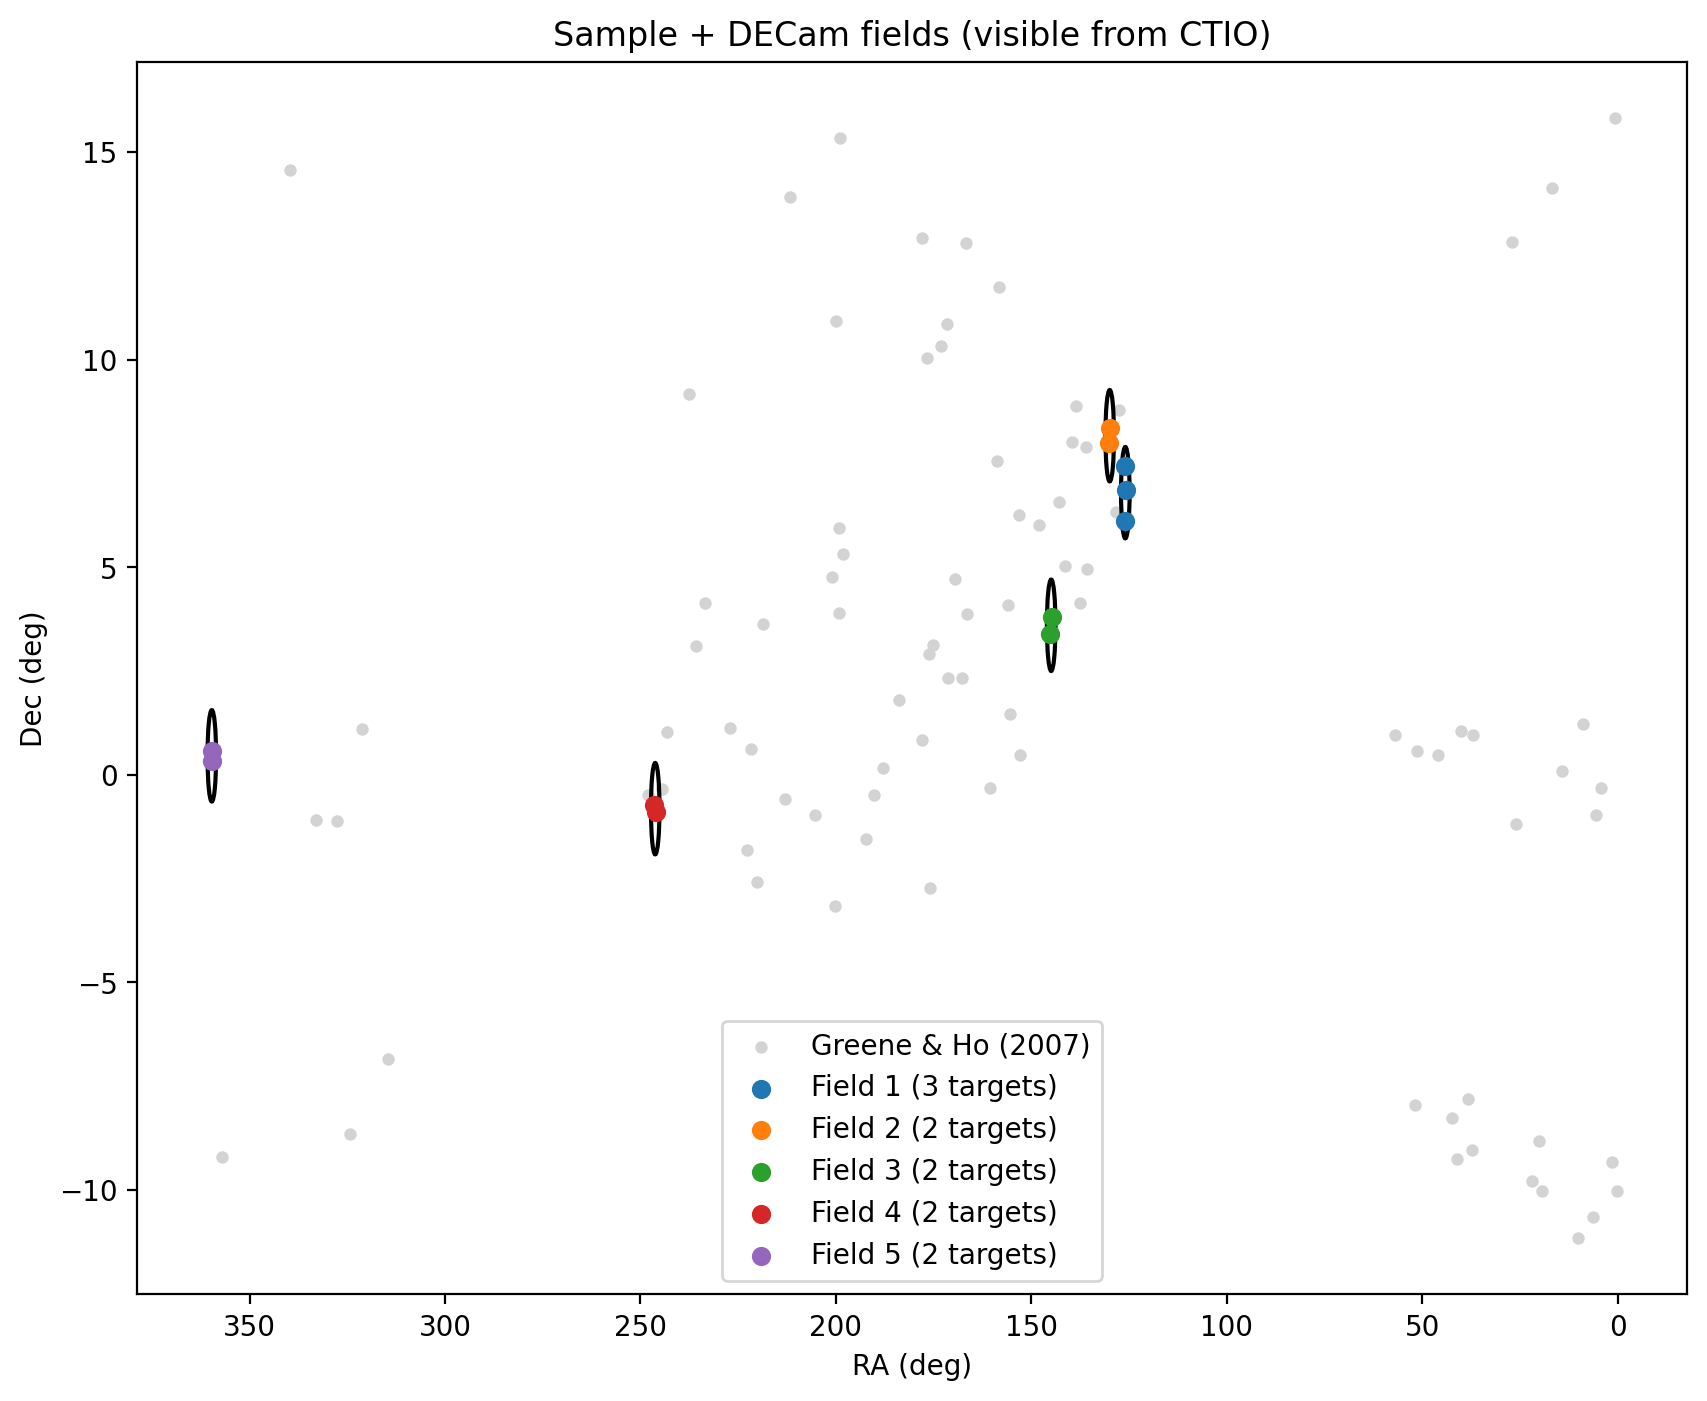

In [28]:
# Plot DECam fields
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Plot all targets in background
ax.scatter(ra, dec, s=12, c='lightgray', label='Greene & Ho (2007)', zorder=1)

for i, members in enumerate(selected_clusters):
    # Plot cluster members
    ax.scatter(ra[members], dec[members], s=35,
               label=f'Field {i+1} ({len(ra[members])} targets)', zorder=3)

    # --- Define field center as mean position ---
    center_ra = np.mean(ra[members])
    center_dec = np.mean(dec[members])

    # --- Draw DECam field (1.1 degree radius) ---
    decam_radius = 1.1  # degrees

    circle = Circle((center_ra, center_dec),
                    decam_radius,
                    edgecolor='k',
                    facecolor='none',
                    lw=1.5,
                    zorder=2)

    ax.add_patch(circle)

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sample + DECam fields (visible from CTIO)")
#ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(dec))), adjustable='box')
ax.invert_xaxis()
ax.legend()


#plt.ylim(-45,45)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


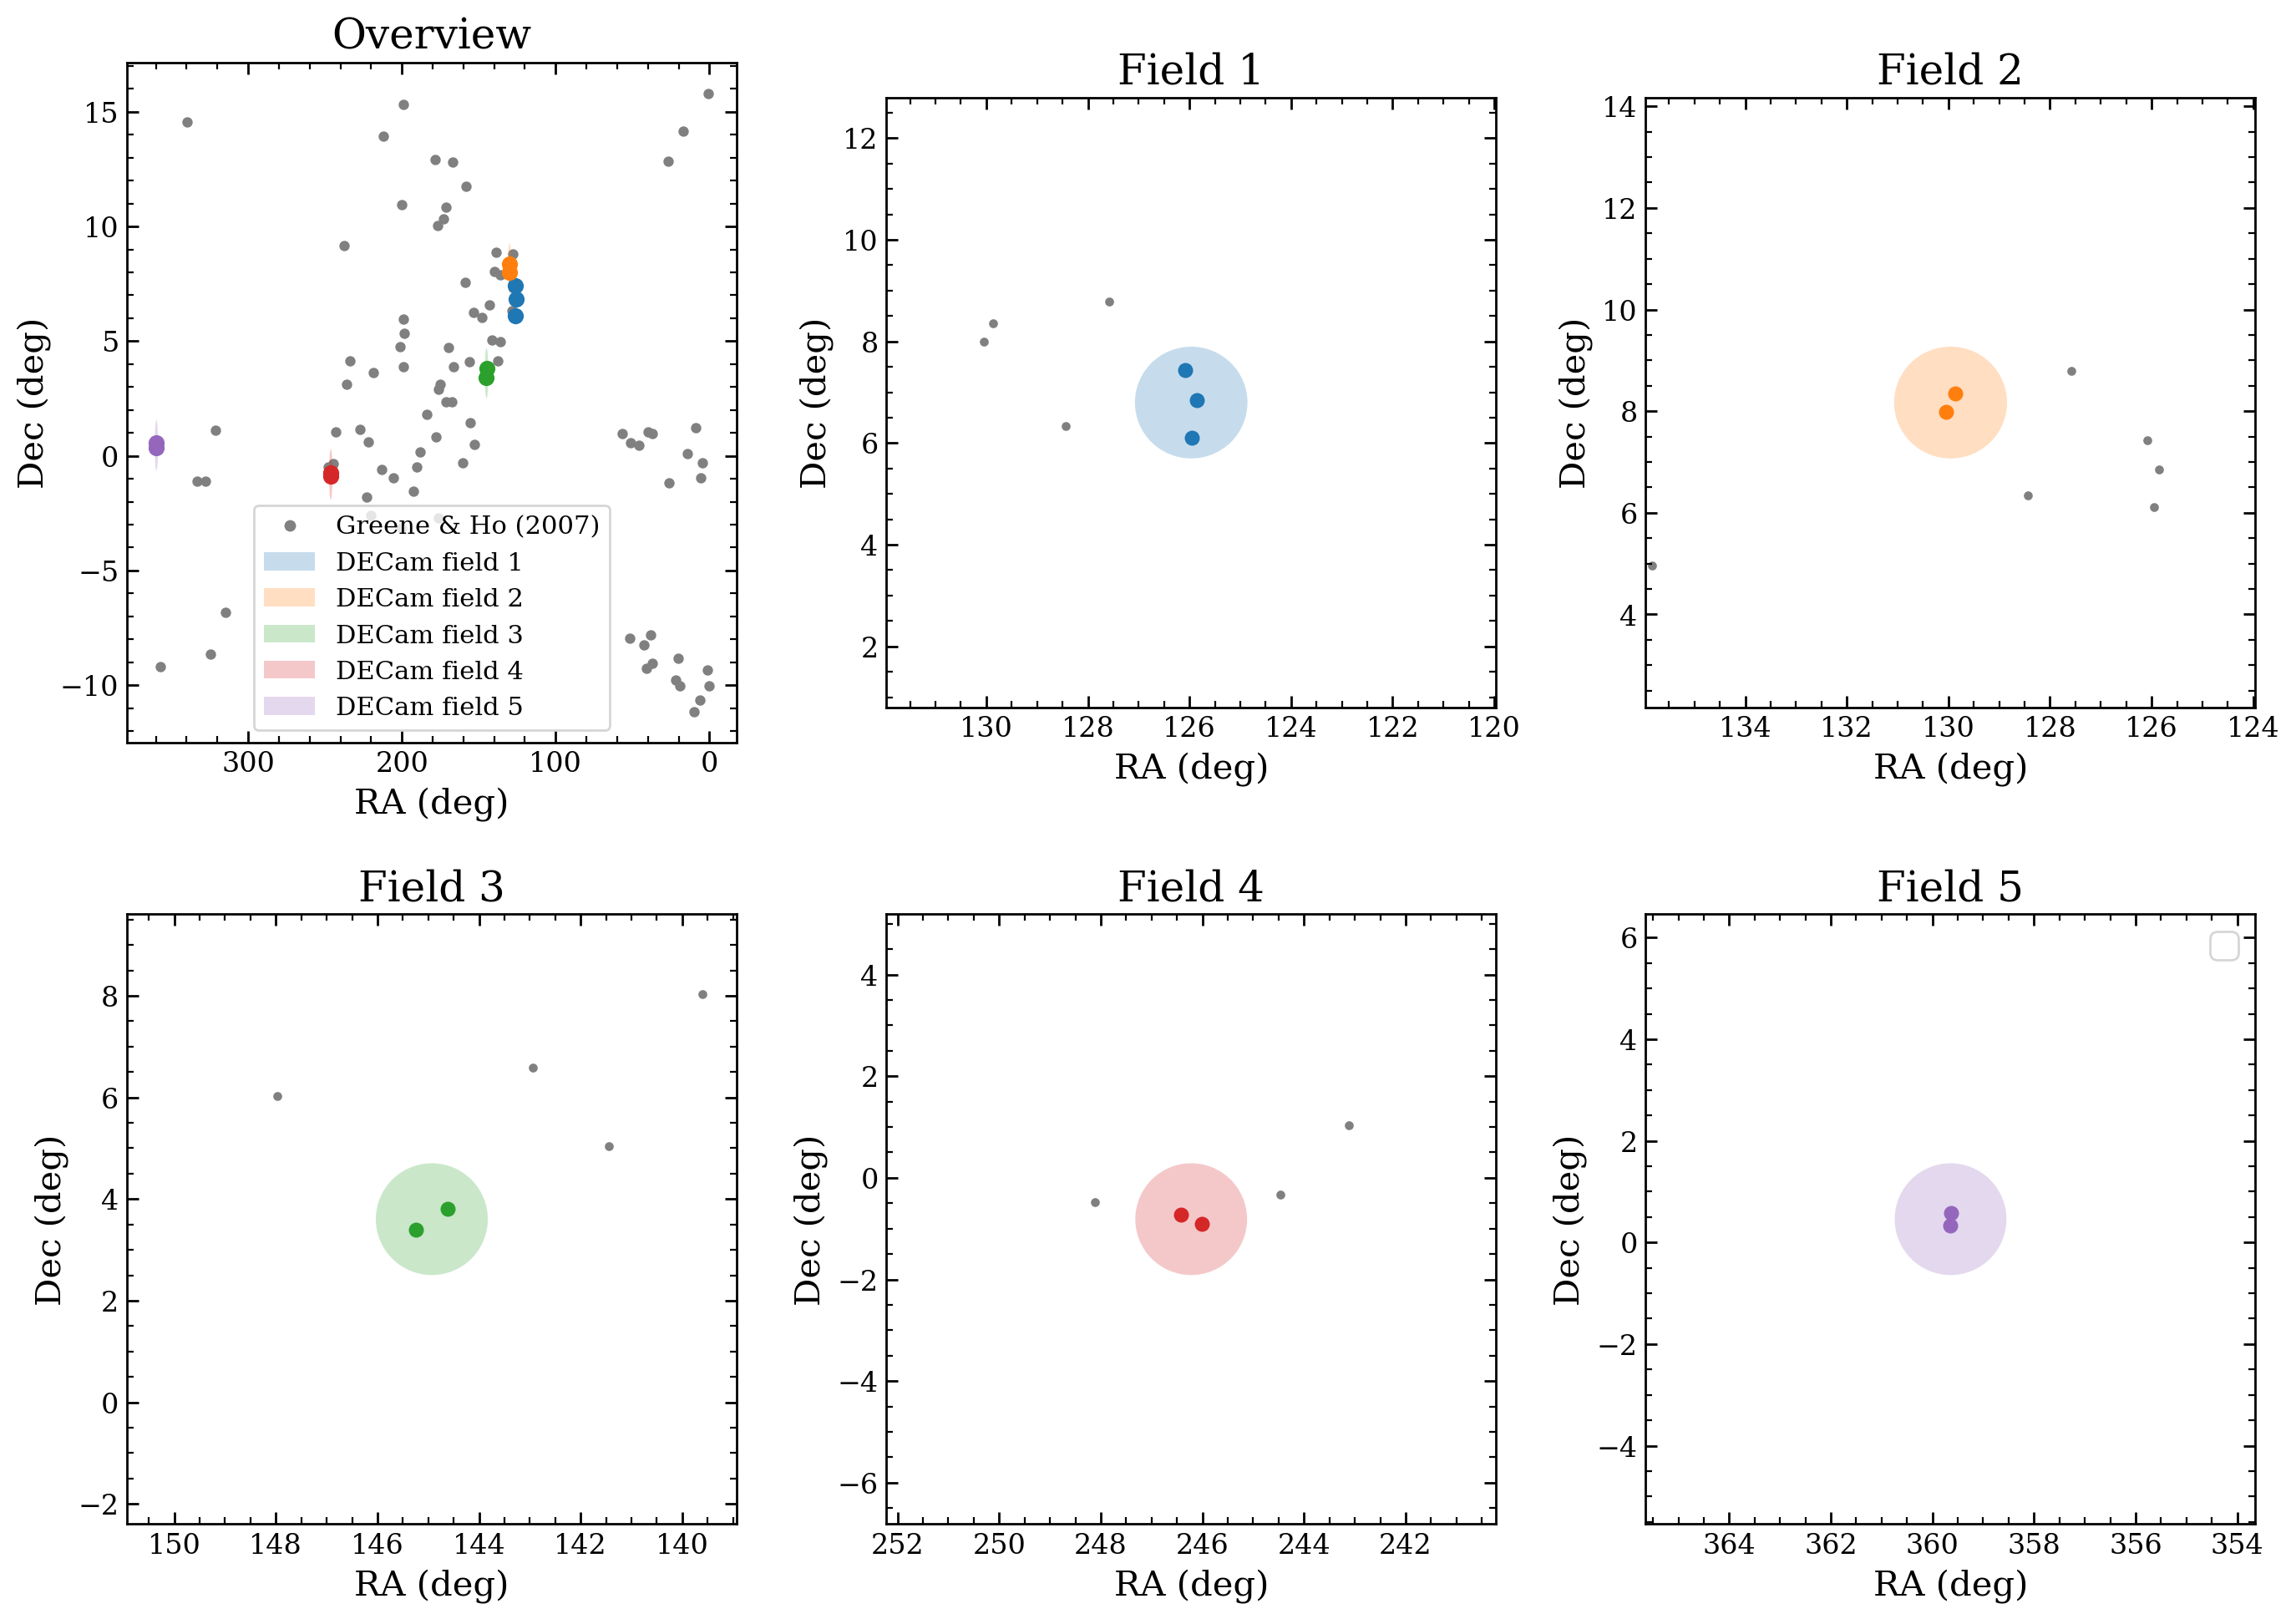

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import rcParams

# -----------------------------
# Academic / publication style
# -----------------------------
plt.style.use('default')
rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
})

# --- Settings ---
decam_radius = 1.1  # degrees

# Manually choose field colors here
field_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
]

if len(field_colors) < len(selected_clusters):
    raise ValueError("Not enough colors in field_colors for the number of selected_clusters.")

# --- Layout: 2x3 equal panels ---
fig, axes = plt.subplots(2, 3, figsize=(14, 10), dpi=200)
axes = axes.flatten()

# ======================
# Panel 0: Overview
# ======================
ax = axes[0]

ax.scatter(ra, dec, s=12, c='gray', zorder=1)

for i, members in enumerate(selected_clusters):
    color = field_colors[i]

    ax.scatter(ra[members], dec[members], s=35, color=color, zorder=3, label="Greene & Ho (2007)")

    center_ra = np.mean(ra[members])
    center_dec = np.mean(dec[members])

    width = 2 * decam_radius / np.cos(np.deg2rad(center_dec))
    height = 2 * decam_radius

    footprint = Ellipse(
        (center_ra, center_dec),
        width=width,
        height=height,
        facecolor=color,
        edgecolor='none',
        alpha=0.25,
        zorder=2
    )
    ax.add_patch(footprint)

ax.set_title("Overview")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.invert_xaxis()

ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.legend()

# ======================
# Panels 1–5: Zoom fields
# ======================
for i in range(len(selected_clusters)):
    ax = axes[i + 1]
    members = selected_clusters[i]
    color = field_colors[i]

    center_ra = np.mean(ra[members])
    center_dec = np.mean(dec[members])

    ax.scatter(ra, dec, s=8, c='gray', alpha=1, zorder=1)
    ax.scatter(ra[members], dec[members], s=30, color=color, zorder=3)

    width = 2 * decam_radius / np.cos(np.deg2rad(center_dec))
    height = 2 * decam_radius

    footprint = Ellipse(
        (center_ra, center_dec),
        width=width,
        height=height,
        facecolor=color,
        edgecolor='none',
        alpha=0.25,
        zorder=2
    )
    ax.add_patch(footprint)

    # tighter zoom
    pad = 6
    ax.set_xlim(center_ra + pad, center_ra - pad)
    ax.set_ylim(center_dec - pad, center_dec + pad)

    ax.set_title(f"Field {i+1}")
    ax.set_aspect('equal', adjustable='box')

    ax.set_ylabel("Dec (deg)")
    ax.set_xlabel("RA (deg)")

    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

# Hide unused panel (6th if only 5 fields)
for j in range(len(selected_clusters) + 1, 6):
    axes[j].axis('off')


# --- Custom legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray', markersize=6,
           label='Greene & Ho (2007)'),

]

# Add each field color
for i, color in enumerate(field_colors):

    legend_elements.append(Patch(facecolor=color, alpha=0.25, edgecolor='none',
          label=f'DECam field {i+1}'))

axes[0].legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()

In [80]:
centers_ra = []
centers_dec = []

for members in selected_clusters:
    centers_ra.append(np.mean(ra[members]))
    centers_dec.append(np.mean(dec[members]))
coords = SkyCoord(ra=centers_ra*u.deg, dec=centers_dec*u.deg)

# Pairwise separations
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        sep = coords[i].separation(coords[j])
        print(f"Field {i+1} - Field {j+1}: {sep.deg:.2f} deg")

Field 1 - Field 2: 4.19 deg
Field 1 - Field 3: 19.15 deg
Field 1 - Field 4: 120.13 deg
Field 1 - Field 5: 125.96 deg
Field 2 - Field 3: 15.57 deg
Field 2 - Field 4: 116.10 deg
Field 2 - Field 5: 129.74 deg
Field 3 - Field 4: 101.32 deg
Field 3 - Field 5: 145.07 deg
Field 4 - Field 5: 113.43 deg


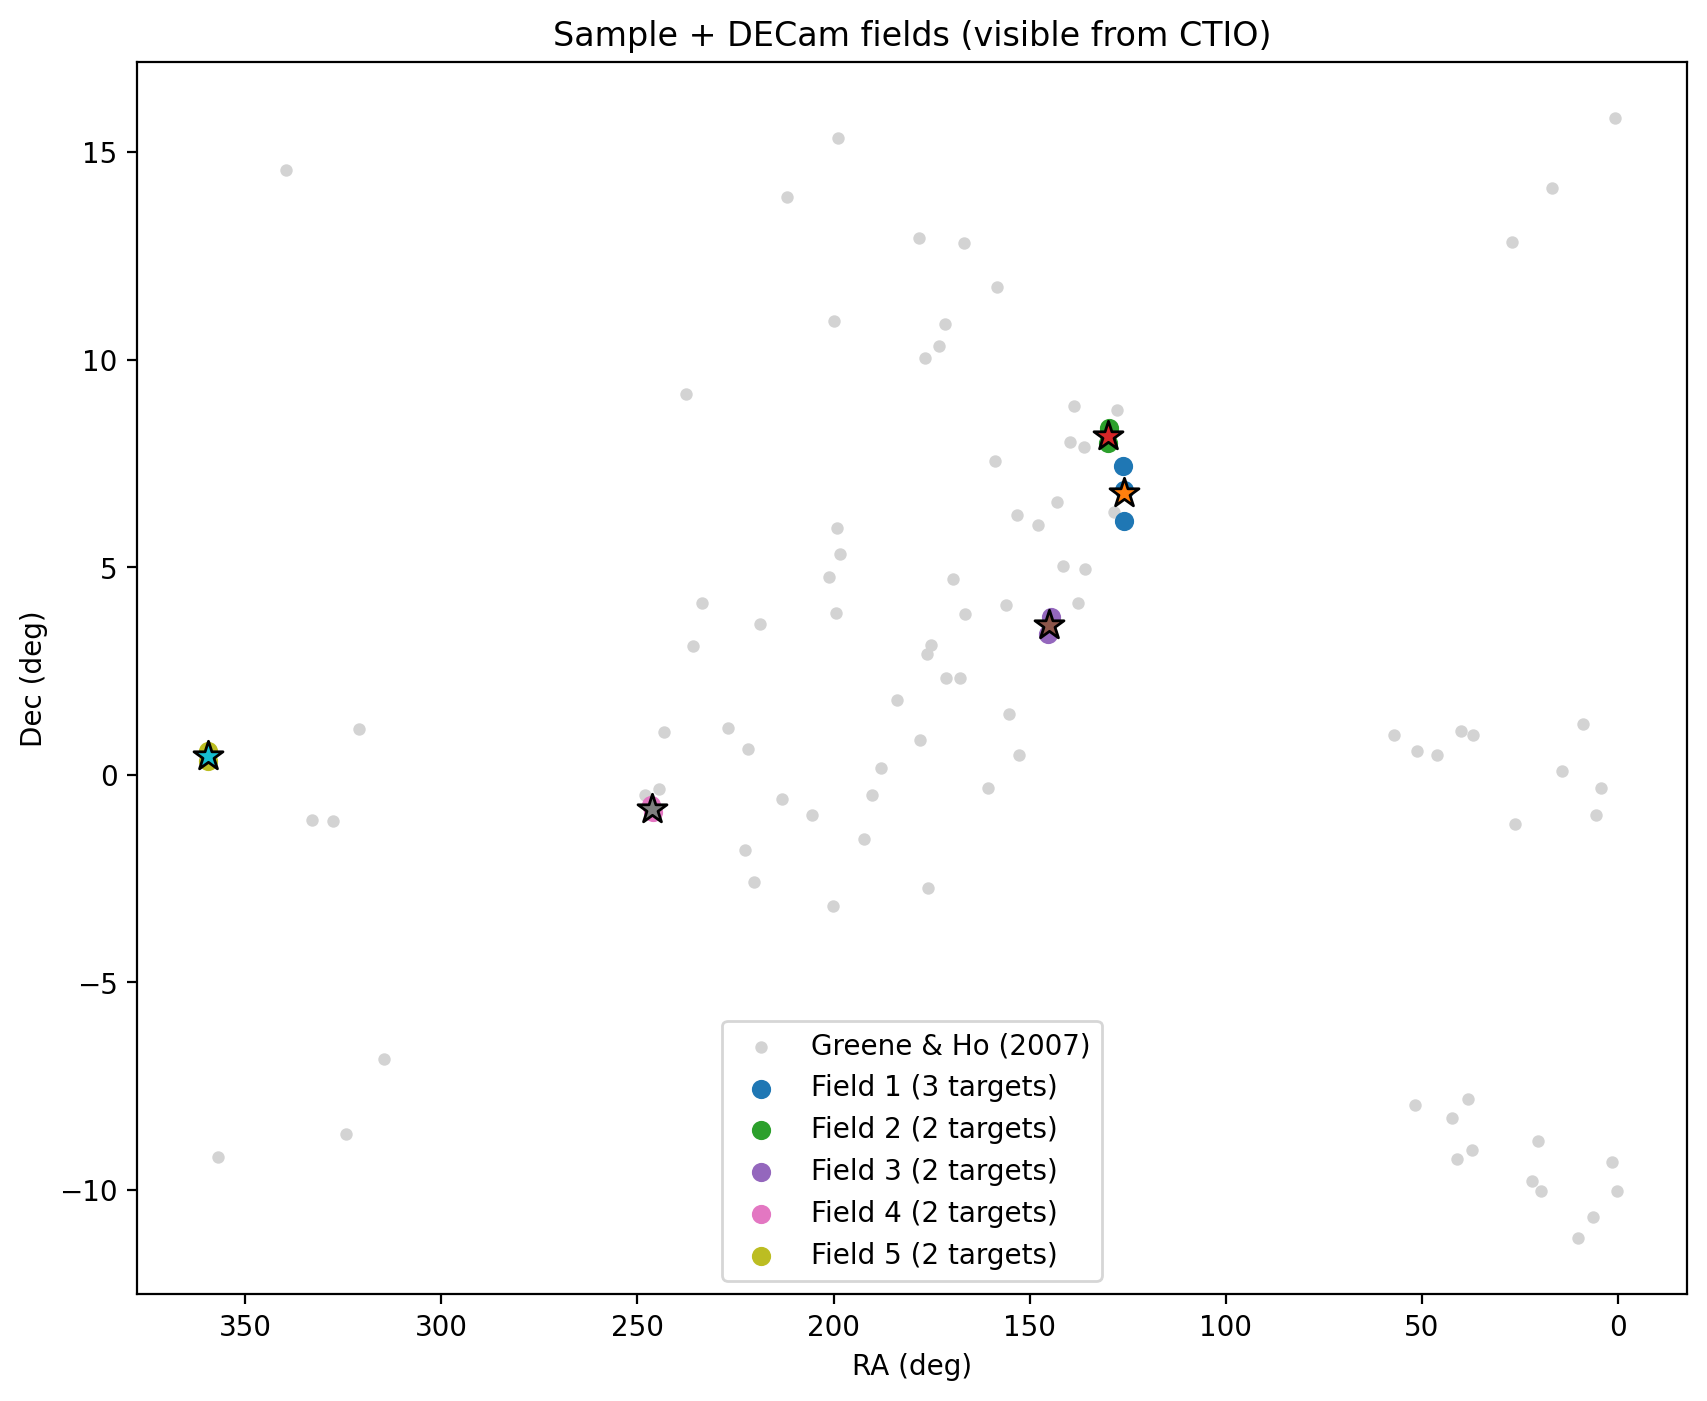

In [19]:
#Plot DECam fields
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Plot all targets in background
ax.scatter(ra, dec, s=12, c='lightgray', label='Greene & Ho (2007)', zorder=1)


for i, members in enumerate(selected_clusters):
    # Plot cluster members
    ax.scatter(ra[members], dec[members], s=35, label=f'Field {i+1} ({len(ra[members])} targets)', zorder=3)

    # --- Define field center as mean position ---
    center_ra = np.mean(ra[members])
    center_dec = np.mean(dec[members])

    # Mark center
    ax.scatter(center_ra, center_dec, s=120, marker='*', edgecolor='k', zorder=4)


ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sample + DECam fields (visible from CTIO)")
ax.invert_xaxis()
#ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.show()

In [60]:
indices = np.concatenate(selected_clusters)
proposal_sample = final_sample[indices]
print(proposal_sample)

Seq         SDSS           z    Sloan ... name1 modelMag_g modelMag_r
                                      ...                            
--- ------------------- ------- ----- ... ----- ---------- ----------
 28 J073106.86+392644.6  0.0483 Sloan ...    26   15.88726   15.20003
 29 J073505.65+423545.6  0.0858 Sloan ...    27   18.33564   17.75135
 30 J074423.44+243046.3  0.1170 Sloan ...    28   18.00643   17.18887
 33 J074831.91+464455.4  0.0883 Sloan ...    31   19.67098   19.18589
 34 J074836.80+182154.2  0.0712 Sloan ...    32   18.09637   17.11452
 43 J082106.95+404836.5  0.1240 Sloan ...    40   19.19922   18.75503
 44 J082325.91+065106.4  0.0724 Sloan ...    41   17.02154   16.42883
 92 J102703.90+485023.9  0.1480 Sloan ...    87   18.31656   17.42957
 93 J102957.76+431430.8  0.0853 Sloan ...    88    17.5289   16.92542
103 J105424.29+454130.5  0.0639 Sloan ...    97   17.28227   16.67098
104 J105755.66+482502.0  0.0732 Sloan ...    98   18.18621   17.67813


In [61]:
print(proposal_sample['modelMag_g'].max())

19.67098


#### $\textbf{DECam Fielding Result}$
Given the wide sky distribution of the parent sample, I select targets located within common DECam fields to maximize observational efficiency. This results in a subset of 25 objects across 12 fields.

### Making $\LaTeX$ Table

In [62]:
table = proposal_sample['SDSS', '_RA', '_DE', 'z', 'modelMag_g', 'modelMag_r', 'logMBH', 'logLbol']
table['_RA'].format = '.4f'
table['_DE'].format = '.4f'
table['z'].format = '.3f'
table['modelMag_g'].format = '.2f'
table['modelMag_r'].format = '.2f'
table['logMBH'].format='.3f'
table['logLbol'].format='.3f'

In [63]:
table

SDSS,_RA,_DE,z,modelMag_g,modelMag_r,logMBH,logLbol
,deg,deg,,,,log(solMass),
bytes19,float64,float64,float32,float64,float64,float32,float32
J073106.86+392644.6,112.7786,39.4457,0.048,15.89,15.20,6.100,-0.800
J073505.65+423545.6,113.7735,42.5960,0.086,18.34,17.75,6.200,-0.400
J074423.44+243046.3,116.0977,24.5129,0.117,18.01,17.19,6.200,-1.100
J074831.91+464455.4,117.1330,46.7487,0.088,19.67,19.19,6.300,-0.700
J074836.80+182154.2,117.1533,18.3651,0.071,18.10,17.11,6.100,-1.400
J082106.95+404836.5,125.2790,40.8101,0.124,19.20,18.76,6.100,-0.300
J082325.91+065106.4,125.8580,6.8518,0.072,17.02,16.43,5.800,-1.300
J102703.90+485023.9,156.7662,48.8400,0.148,18.32,17.43,6.300,-0.900


In [64]:
table.write('targets.tex', format='ascii.latex', overwrite=True)